# Exploratory Data Analysis (EDA) HW 2

This notebook will run through an Exploratory Data Analysis (EDA) of a coastal cleanup dataset with some guidelines from the HW 2 directions. I plan to explore the size of the dataset, number of missing values, data types, calculating some descriptive statistics, looking for correlations, etc. We will use data on beach cleanups in the area of Norfolk, VA that can downloaded from here: 
https://data.norfolk.gov/Environment/International-Coastal-Cleanup/frs3-vh3y/about_data

This data was originally collected as part of the International Coastal Cleanup initiative, but data was sourced from Norfolk Open Data and Keep Norfolk Beautiful. Description and additional information can be found at:
https://data.norfolk.gov/Environment/International-Coastal-Cleanup/frs3-vh3y/about_data

I will be using `International_Coastal_Cleanup.csv` file in the `data` folder of my repository.

In [10]:
# Load in the packages you will need for your analysis

import pandas as pd  # pandas is a package for data analysis and manipulation
import seaborn as sea  # seaborn is a data visualization package
import matplotlib.pyplot as plt # matplotlib is the OG python plotting library and really useful for formatting 
import cartopy as crt  # cartopy is a package for geospatial data processing

In [11]:
# Load in the csv file with coastal cleanup data

# Set the path to the correct directory for your particular computer
infile = 'C:/Users/jtgal/OEAS805/DATA/International_Coastal_Cleanup.csv'

# Read in the .csv file with the column separator explicitly defined
data = pd.read_csv(infile, sep = ',')

In [12]:
# Print the information about the data in the dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Area                                       77 non-null     str    
 1   Date                                       77 non-null     str    
 2   Cigarette Butts                            77 non-null     str    
 3   Food Wrappers (candy, chips, etc.)         77 non-null     str    
 4   Take Out/Away Containers (Plastic)         77 non-null     int64  
 5   Take Out/Away Containers (Foam)            77 non-null     int64  
 6   Bottle Caps (Plastic)                      77 non-null     int64  
 7   Bottle Caps (Metal)                        77 non-null     str    
 8   Lids (Plastic)                             77 non-null     int64  
 9   Straws, Stirrers                           77 non-null     int64  
 10  Forks, Knives, Spoons                  

Bullet 2:
    Data Types - str, int64, float64
    
    Mix of 3 different data types; including string (str), 64-bit signed integer (int64), and 64-bit double-precision floating-point number (float64). For some columns this will cause issues later.

Bullet 3:
    All data columns have 77 data points.

In [13]:
# Read the CSV, treating commas within numbers as thousands separators
data = pd.read_csv(infile, sep=',', thousands=',')

# Convert every column after Area and Date to a numeric dtype to avoid errors with different data types
value_columns = data.columns[2:]
data[value_columns] = data[value_columns].apply(pd.to_numeric, errors='raise')

In [14]:
# Print the information about the new corrected data in the dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Area                                       77 non-null     str    
 1   Date                                       77 non-null     str    
 2   Cigarette Butts                            77 non-null     int64  
 3   Food Wrappers (candy, chips, etc.)         77 non-null     int64  
 4   Take Out/Away Containers (Plastic)         77 non-null     int64  
 5   Take Out/Away Containers (Foam)            77 non-null     int64  
 6   Bottle Caps (Plastic)                      77 non-null     int64  
 7   Bottle Caps (Metal)                        77 non-null     int64  
 8   Lids (Plastic)                             77 non-null     int64  
 9   Straws, Stirrers                           77 non-null     int64  
 10  Forks, Knives, Spoons                  

Bullet 2:
    Data Types - str, int64, float64
    
    Mix of 3 different data types; including string (str), 64-bit signed integer (int64), and 64-bit double-precision floating-point number (float64). Now the data types are a lot more fitting with the data that they are describing.

Bullet 3:
    All data columns have 77 data points.

In [15]:
# The shape of the data
# nrows, ncols

data.shape

(77, 53)

In [16]:
# Total number of datapoints in the dataframe
# ncol * nrows

data.size

4081

Bullet 1:

    Variables - 53 columns or variables 
    These variables contain area of sampling, date sampled, different types of trash collected, # of volunteers, # of hours, # of miles
    Samples - 77 rows (0 to 76), these indicate values for each different sampled location
    Total Size - 77 x 53, 4081 total size

In [17]:
# Gives a list of the column names in the dataframe

data.columns

Index(['Area', 'Date', 'Cigarette Butts', 'Food Wrappers (candy, chips, etc.)',
       'Take Out/Away Containers (Plastic)', 'Take Out/Away Containers (Foam)',
       'Bottle Caps (Plastic)', 'Bottle Caps (Metal)', 'Lids (Plastic)',
       'Straws, Stirrers', 'Forks, Knives, Spoons',
       'Beverage Bottles (Plastic)', 'Beverage Bottles (Glass)',
       'Beverage Cans', 'Grocery Bags (Plastic)', 'Other Plastic Bags',
       'Paper Bags', 'Cups, Plates (Paper)', 'Cups, Plates (Plastic)',
       'Cups, Plates (Foam)', 'Fishing Buoys, Pots & Traps',
       'Fishing Net & Pieces', 'Fishing Line (1 yard/meter = 1 piece)',
       'Rope (1 yard/meter = 1 piece)', 'Fishing Gear (Clean Swell)',
       '6-Pack Holders', 'Other Plastic/Foam Packaging',
       'Other Plastic Bottles (oil, bleach, etc.)', 'Strapping Bands',
       'Tobacco Packaging/Wrap', 'Other Packaging (Clean Swell)',
       'Appliances (refrigerators, washers, etc.)', 'Balloons', 'Cigar Tips',
       'Cigarette Lighters', 'Co

In [18]:
# Get a list of the unique locations found in the 'Area' column of the dataframe
data['Area'].unique()

# Assign the list of unique values of 'Area' to a new variable called 'areas'
areas = data['Area'].unique()
print(areas)

<StringArray>
[                                                  'Ocean View Beach Park',
                                                           'Lakewood Park',
                                                         'Plum Point Park',
                                    'Lafayette Park & Lavalette Boat Ramp',
                                                            'Barraud Park',
                        'The Academy Of International Studies At Rosemont',
                                                       'Harbor Park (ERT)',
                                                         'Ocean View Park',
                                     'East Ocean View (1300 - 1900 Block)',
                               'Bayview Elementary/East Bayview Boulevard',
                                                      'ODU/Lamberts Point',
                                              'East Ocean View Rec Center',
                                                         'East Ocean View'

Outlining the 36 unique sites that coastal cleanup occurred at.

In [19]:
# Descriptive statistics for all numeric columns (The only 2 columns not included here are Area & Date)

pd.set_option("display.max_columns", None)
data.describe(include="number")

,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Bottles (Glass),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,Paper Bags,"Cups, Plates (Paper)","Cups, Plates (Plastic)","Cups, Plates (Foam)","Fishing Buoys, Pots & Traps",Fishing Net & Pieces,Fishing Line (1 yard/meter = 1 piece),Rope (1 yard/meter = 1 piece),Fishing Gear (Clean Swell),6-Pack Holders,Other Plastic/Foam Packaging,"Other Plastic Bottles (oil, bleach, etc.)",Strapping Bands,Tobacco Packaging/Wrap,Other Packaging (Clean Swell),"Appliances (refrigerators, washers, etc.)",Balloons,Cigar Tips,Cigarette Lighters,Construction Materials,Fireworks,Tires,Toys,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000
mean,480.194805,154.220779,18.363636,13.714286,98.337662,245.376623,23.350649,50.558442,13.909091,68.922078,44.987013,44.350649,38.961039,36.233766,15.116883,21.285714,19.376623,19.207792,0.636364,2.103896,4.779221,5.590909,0.558442,1.870130,27.909091,3.129870,4.493506,33.987013,2.714286,0.571429,5.571429,35.792208,3.740260,10.909091,1.272727,0.857143,0.168831,18.961039,1.909091,1.259740,0.61039,0.922078,39.116883,64.441558,119.558442,267.233766,2059.474026,200.558442,18.896104,37.37013,1.530909
std,832.501510,219.833108,21.944253,18.943724,148.793093,924.419064,26.738877,62.141920,20.238825,92.227089,143.478725,55.825331,59.709922,77.109269,32.100571,38.343275,27.973220,40.714454,1.700689,3.740196,12.906163,16.172330,2.643231,4.832322,48.928568,5.184366,7.849947,61.799015,13.069508,1.794939,9.255764,64.068290,7.831116,18.400645,4.204122,1.978265,0.864544,67.232989,4.205829,3.743073,1.94771,2.113654,239.313600,128.515767,359.613370,875.693753,3408.767664,379.650445,27.249135,57.04352,1.486711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,50.000000,26.000000,3.000000,1.000000,16.000000,1.000000,6.000000,11.000000,1.000000,15.000000,3.000000,6.000000,5.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,5.000000,337.000000,30.000000,5.000000,9.00000,1.000000
50%,140.000000,64.000000,8.000000,6.000000,43.000000,15.000000,13.000000,24.000000,7.000000,34.000000,13.000000,26.000000,17.000000,10.000000,0.000000,8.000000,10.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.000000,0.000000,1.000000,11.000000,0.000000,0.000000,1.000000,13.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,14.000000,12.000000,63.000000,851.000000,80.00

Bullet 4: Total count per column, mean, standard deviation (std), minumum (min), 25%, 50%, 75%, and maximum (max) where calculated.


In [20]:
# Using the total count to get to the total number of columns in this table
total_count = data.describe(include="number").loc["count"].sum()
average_count = total_count / 77

print("Number of Columns:", average_count)

# Display the means and standard deviations for each of the columns in this table vertically
mean_std = data.select_dtypes(include="number").agg(["mean", "std"]).T
mean_std.columns = ["Mean", "Standard Deviation"]

display(mean_std)

Number of Columns: 51.0


,Mean,Standard Deviation
Cigarette Butts,480.194805,832.501510
"Food Wrappers (candy, chips, etc.)",154.220779,219.833108
Take Out/Away Containers (Plastic),18.363636,21.944253
Take Out/Away Containers (Foam),13.714286,18.943724
Bottle Caps (Plastic),98.337662,148.793093
Bottle Caps (Metal),245.376623,924.419064
Lids (Plastic),23.350649,26.738877
"Straws, Stirrers",50.558442,62.141920
"Forks, Knives, Spoons",13.909091,20.238825
Beverage Bottles (Plastic),68.922078,92.227089


    A mean of 98 plastic bottle caps (std 148.8) were found at every site sampled
    Toys, syringes, and tampons/tampon applicators all were found at a mean >1 per site 
    All collected items had standard deviations that were higher than their mean values indicating the high variability of these datasets

    Each location averaged about 19 volunteers and 37 total hours, and 1.53 miles

In [21]:
# Display the maximum and minimum values for each numeric column
max_min = data.select_dtypes(include="number").agg(["max", "min"]).T
max_min.columns = ["Maximum", "Minimum"]

display(max_min)

,Maximum,Minimum
Cigarette Butts,3639.0,0.0
"Food Wrappers (candy, chips, etc.)",1203.0,0.0
Take Out/Away Containers (Plastic),90.0,0.0
Take Out/Away Containers (Foam),106.0,0.0
Bottle Caps (Plastic),780.0,0.0
Bottle Caps (Metal),6269.0,0.0
Lids (Plastic),109.0,0.0
"Straws, Stirrers",368.0,0.0
"Forks, Knives, Spoons",136.0,0.0
Beverage Bottles (Plastic),395.0,0.0


All items had at least one location where 0 of the item were collected (min).
Maximum effort included 178 volunteers, 396 hours, 10 miles covered, and 2545 pounds of litter collected.
Plastic pieces had the highest maximum value collected at a single site, where 7415 were collected at one site (max), while cigarette butts were the closest to follow at 3639.

In [22]:
# Display the 25th, 50th, and 75th percentiles for each numeric column
quartiles = data.select_dtypes(include="number").quantile([0.25, 0.50, 0.75]).T
quartiles.columns = ["25%", "50%", "75%"]

display(quartiles)

,25%,50%,75%
Cigarette Butts,50.0,140.0,439.0
"Food Wrappers (candy, chips, etc.)",26.0,64.0,177.0
Take Out/Away Containers (Plastic),3.0,8.0,31.0
Take Out/Away Containers (Foam),1.0,6.0,19.0
Bottle Caps (Plastic),16.0,43.0,107.0
Bottle Caps (Metal),1.0,15.0,39.0
Lids (Plastic),6.0,13.0,33.0
"Straws, Stirrers",11.0,24.0,72.0
"Forks, Knives, Spoons",1.0,7.0,20.0
Beverage Bottles (Plastic),15.0,34.0,70.0


Median of 11 volunteers, 22 hours, 1 mile, and 80 pounds of litter collected.
Highest median values (50%) were cigarette butts (140) and food wrappers (64).

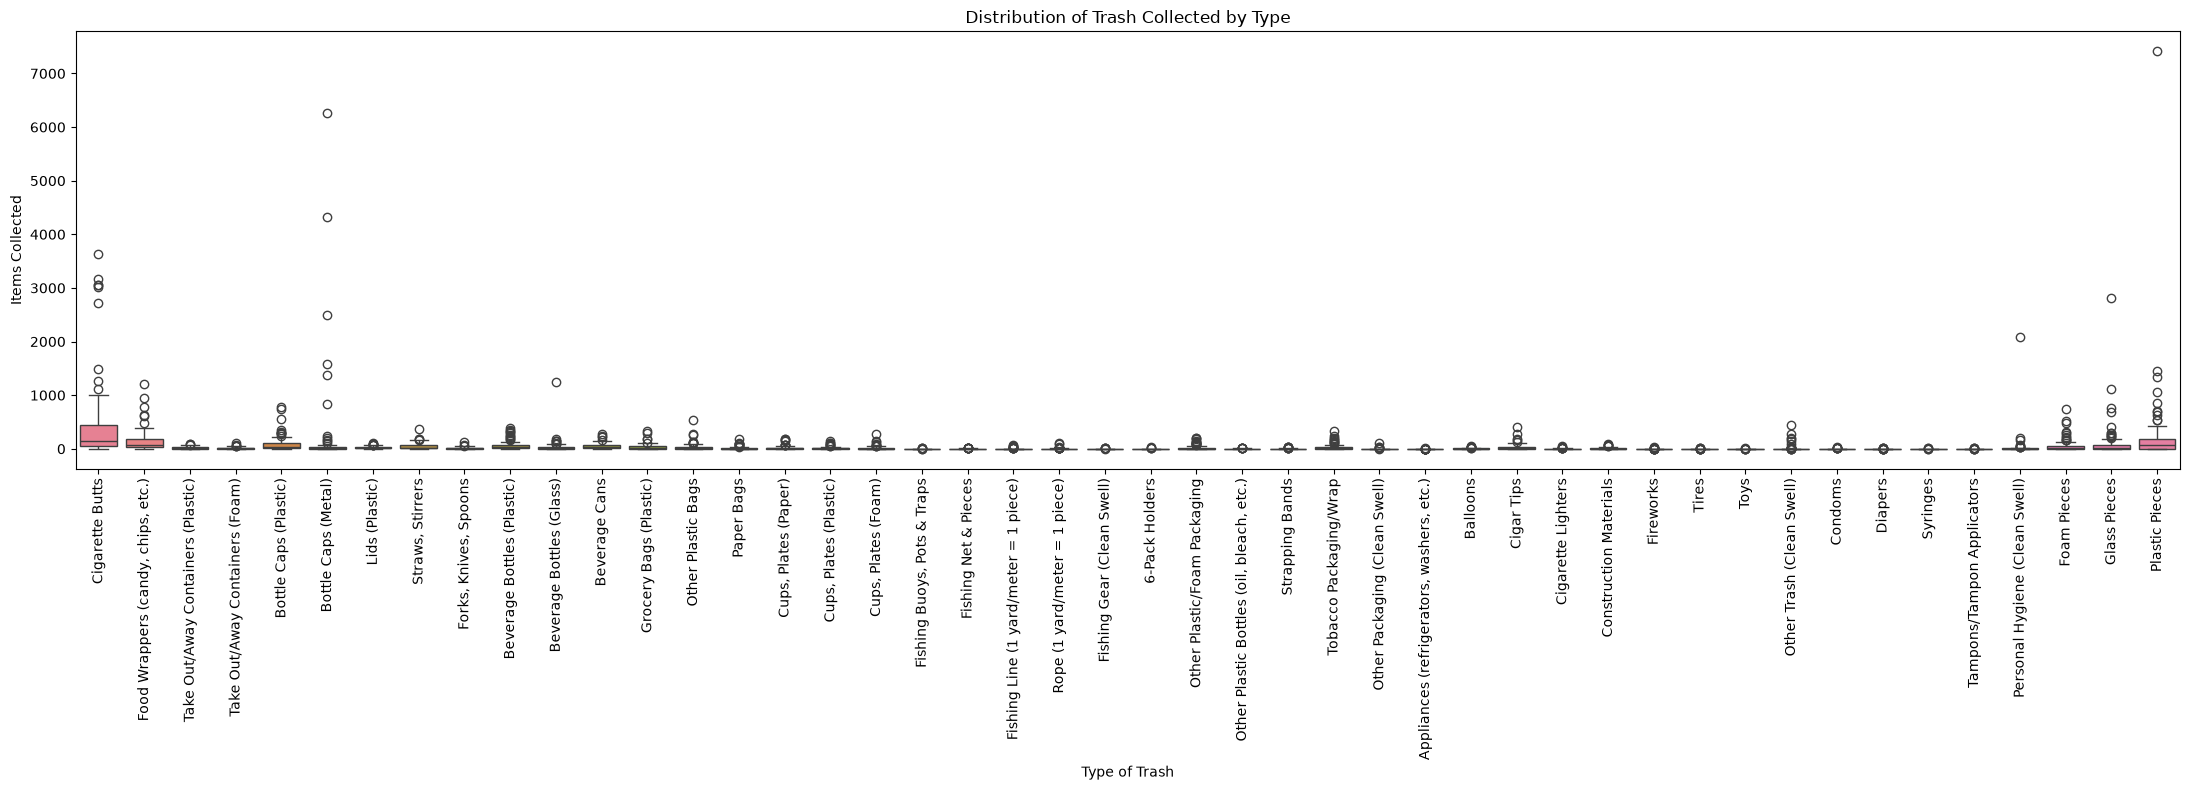

In [23]:
# Make a crude boxplot that shows outliers, but needs to be refined
exclude_columns = [
    "Area",
    "Date",
    "Total Items Collected",
    "Total Pounds of Litter Collected",
    "Number of Volunteers",
    "Volunteer Hours",
    "Number of Miles",
]

trash_data = data.drop(columns=exclude_columns, errors="ignore")

fig, ax = plt.subplots(figsize=(22, 8))
sea.boxplot(data=trash_data, ax=ax)
ax.set_title("Distribution of Trash Collected by Type")
ax.set_xlabel("Type of Trash")
ax.set_ylabel("Items Collected")
ax.tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

This plot helps me see some of the outliers that exist within my dataset. Single major outliers exist in data like glass pieces, personal hygiene, and beverage bottles. Several outliers, well above the box exist for bottle caps and cigarette butts.

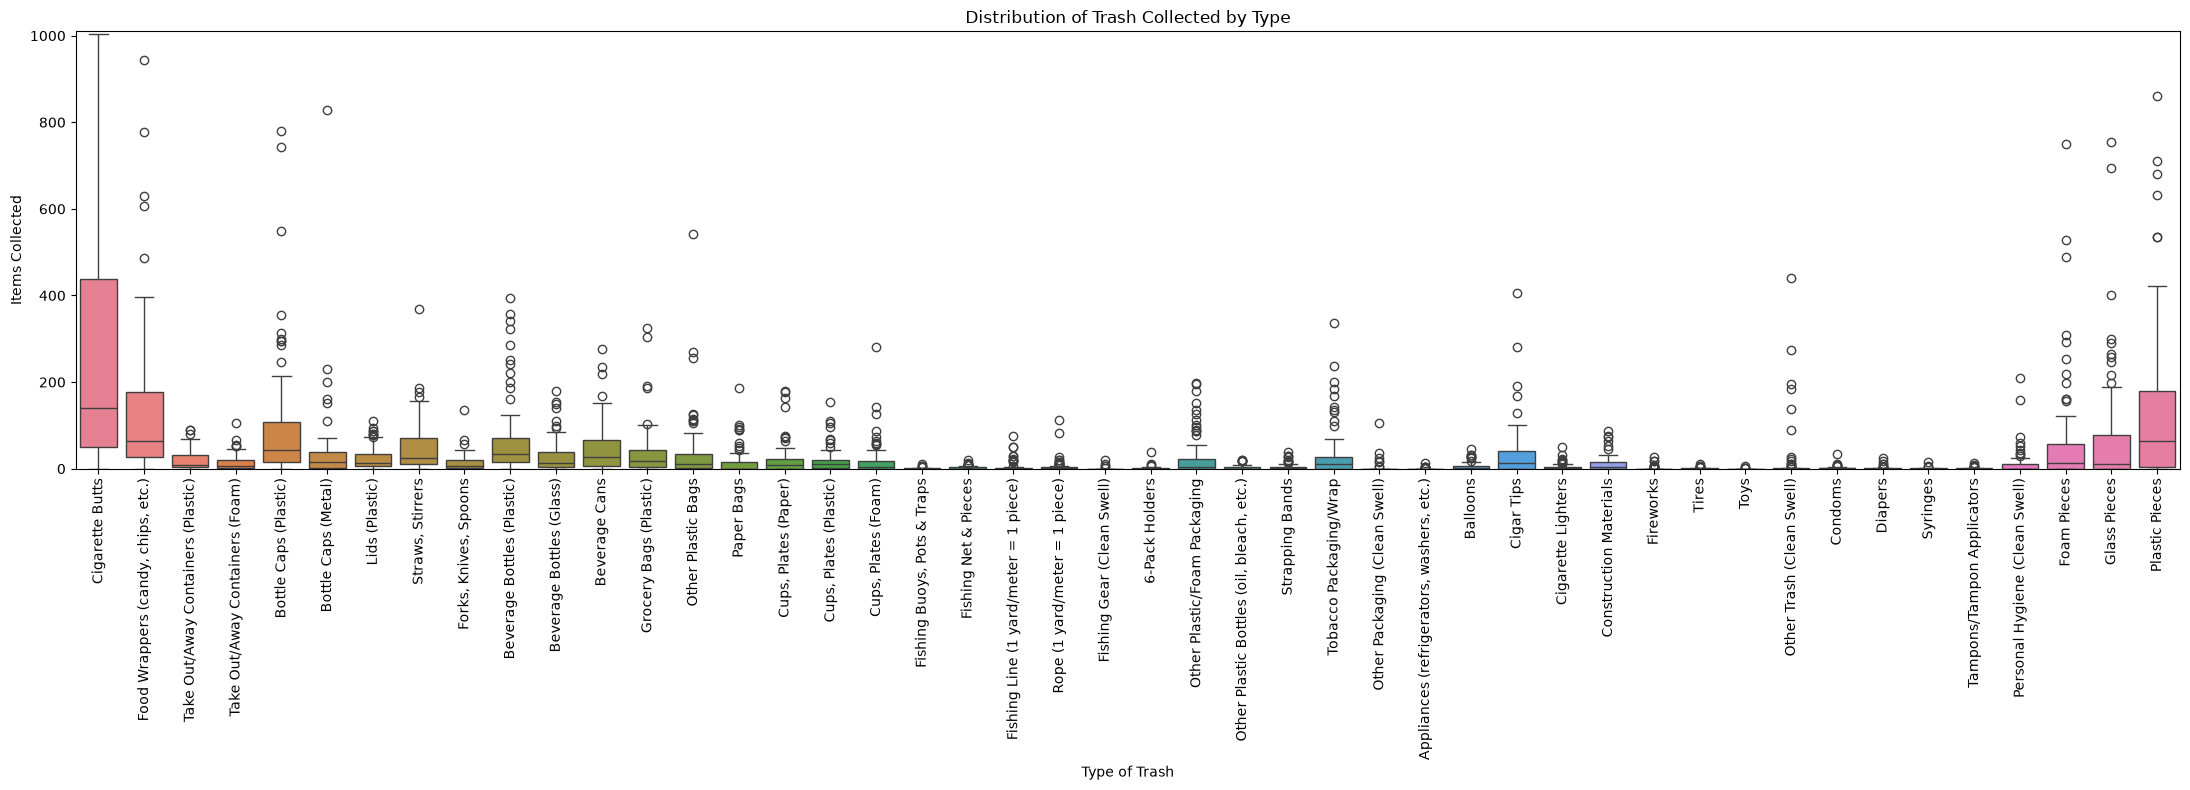

In [24]:
fig_limited, ax_limited = plt.subplots(figsize=(22, 8))
sea.boxplot(data=trash_data, ax=ax_limited)

ax_limited.set_title("Distribution of Trash Collected by Type")
ax_limited.set_xlabel("Type of Trash")
ax_limited.set_ylabel("Items Collected")
ax_limited.set_ylim(0, 1010)
ax_limited.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

This boxplot helps me get a lot more resolution for 25th to 75th quartiles for each type of trash. It shows that cigarette butts still are the highest, but others like food wrappers, foam pieces, glass pieces, and plastic pieces are all fairly high as well. Cigar tips, beverage cans, straws, and bottle caps also stand out as being higher.

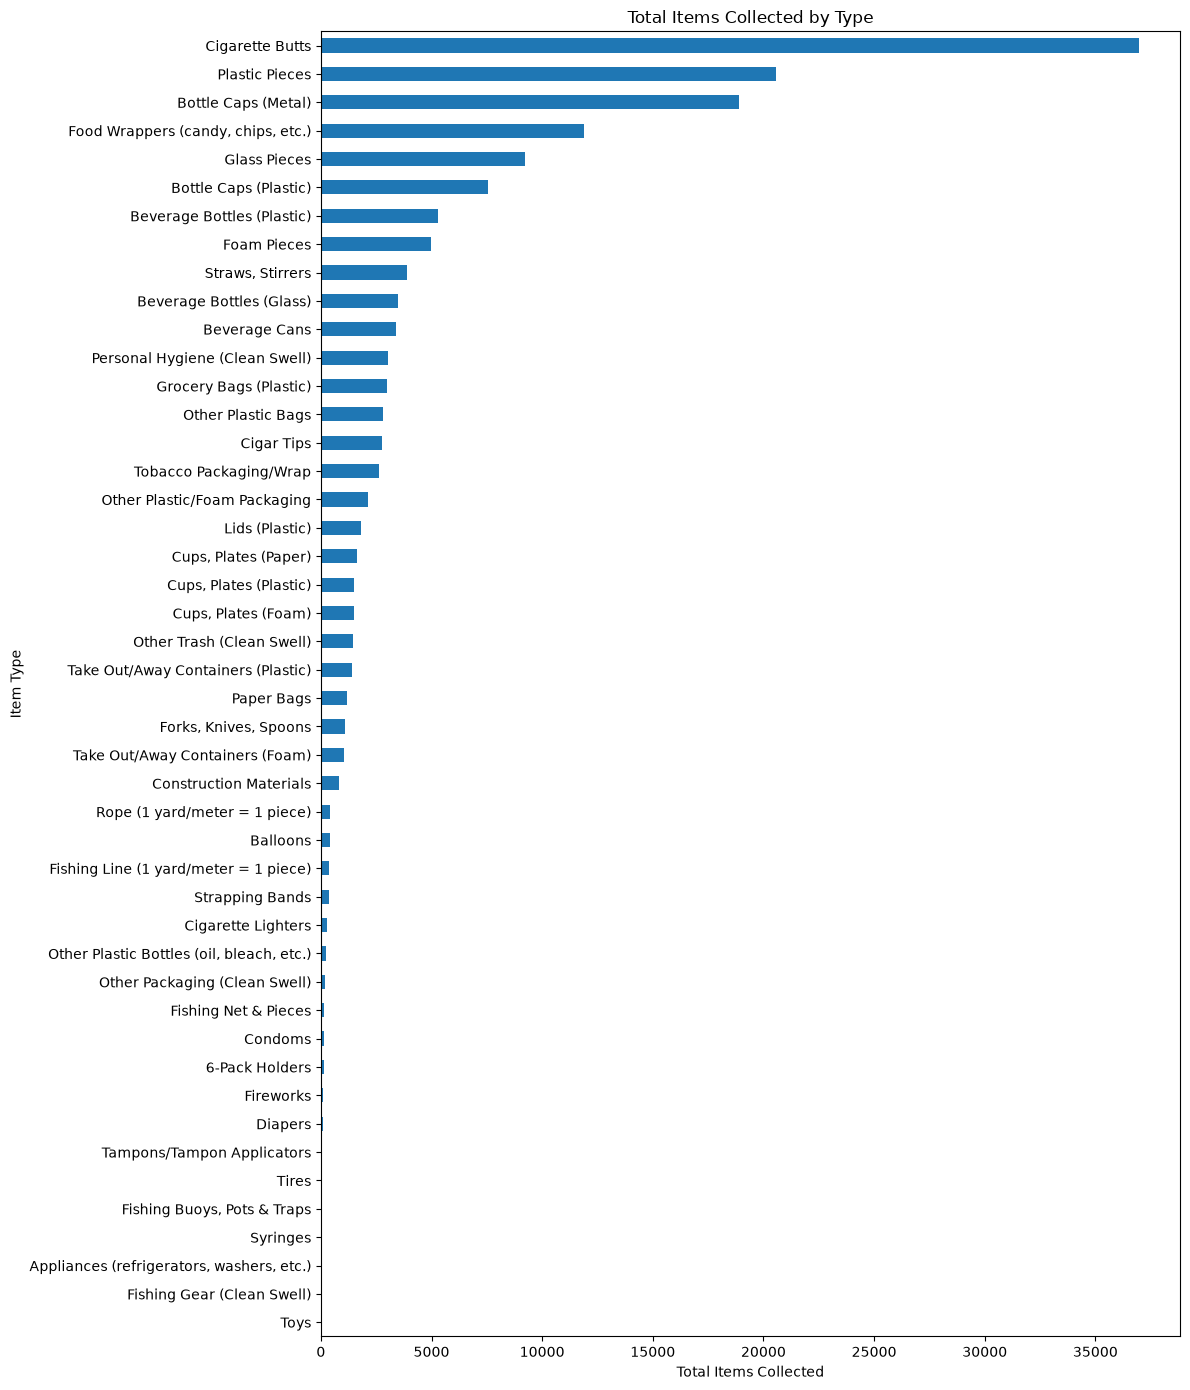

In [25]:
item_totals = trash_data.sum().sort_values()

fig, ax = plt.subplots(figsize=(12, 14))
item_totals.plot(kind="barh", ax=ax)

ax.set_title("Total Items Collected by Type")
ax.set_xlabel("Total Items Collected")
ax.set_ylabel("Item Type")
plt.tight_layout()
plt.show()

This barplot both puts in order what items were found the most among all sites and dates, but also helps to quantify the magnitude of how much more frequently some were found opposed to others. It shows a lot of the categories were only found a couple of times, while only a few were found very frequently and in large numbers.

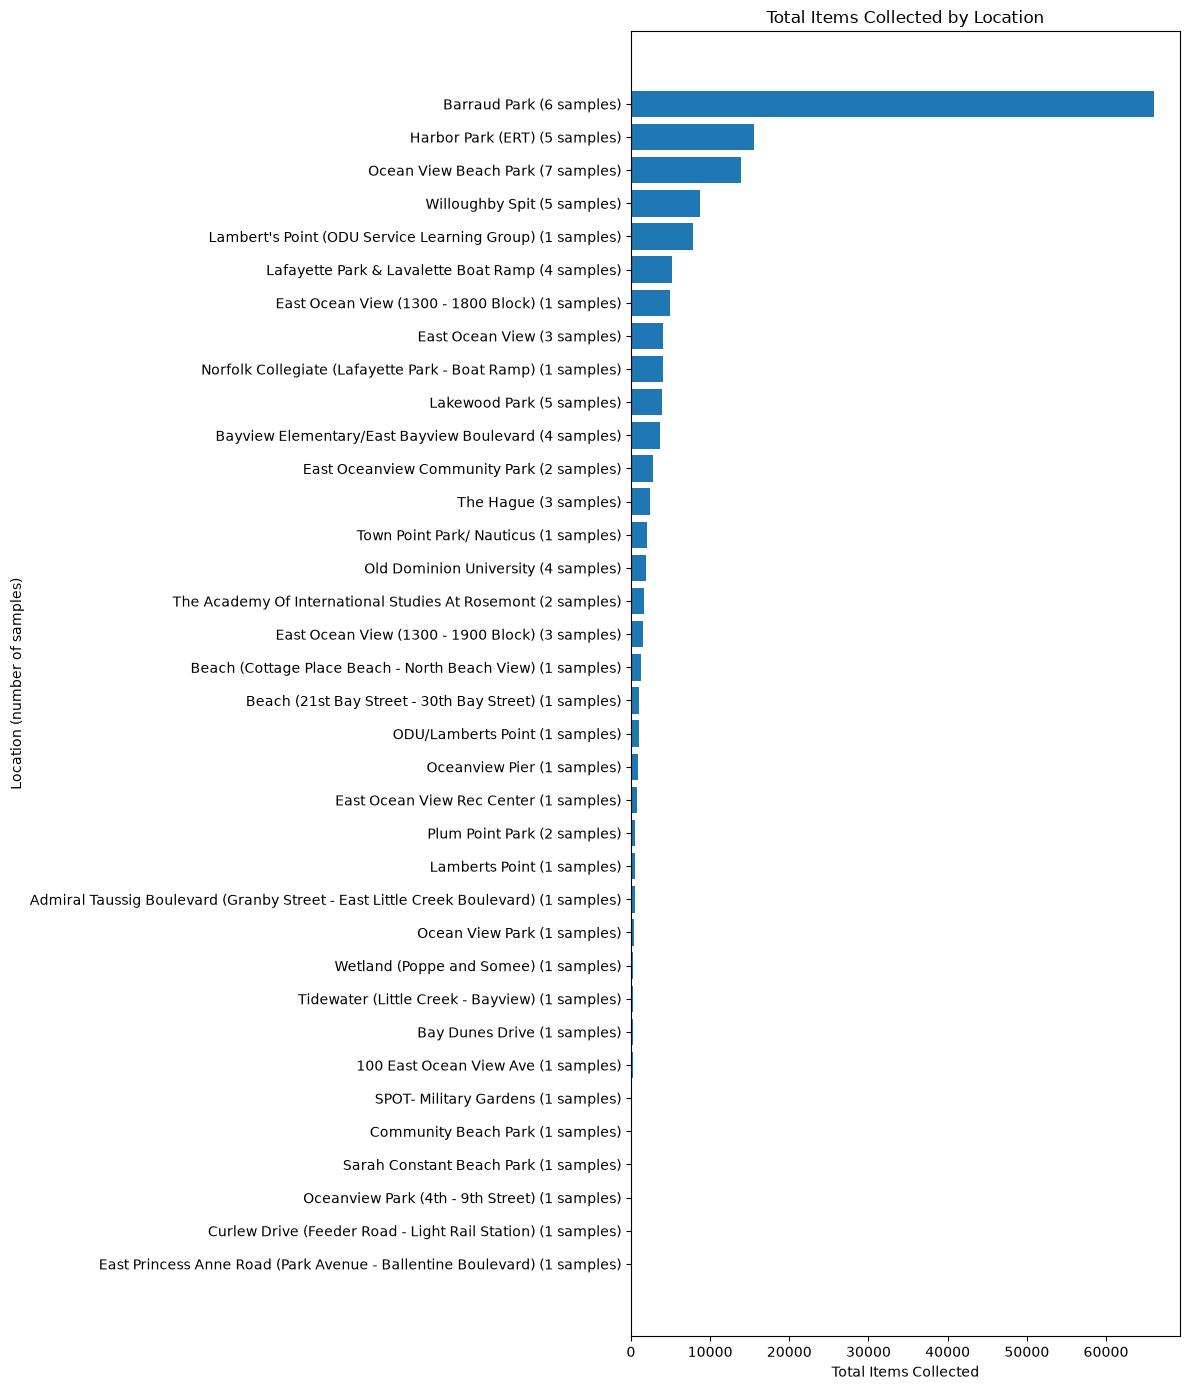

In [26]:
# Sum total items and count the number of samples for each location
location_summary = (
    data.groupby("Area")
    .agg(
        total_items=("Total Items Collected", "sum"),
        sample_count=("Total Items Collected", "count"),
    )
    .sort_values("total_items")
)

# Add the sample count to each location label
location_labels = [
    f"{area} ({count} samples)"
    for area, count in zip(location_summary.index, location_summary["sample_count"])
]

fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(location_labels, location_summary["total_items"])

ax.set_title("Total Items Collected by Location")
ax.set_xlabel("Total Items Collected")
ax.set_ylabel("Location (number of samples)")
plt.tight_layout()
plt.show()

This is another plot taking more of a focus on the location sampled at and how much trash was there. A lot of the sites with higher amounts of trash collected were sampled 5-7 times, more than some of the others with lower numbers of total items collected. Maybe a useful next step launching point from this data would be to take an average based on how many times each was sampled. Used A.I. to help with the summing the totals.

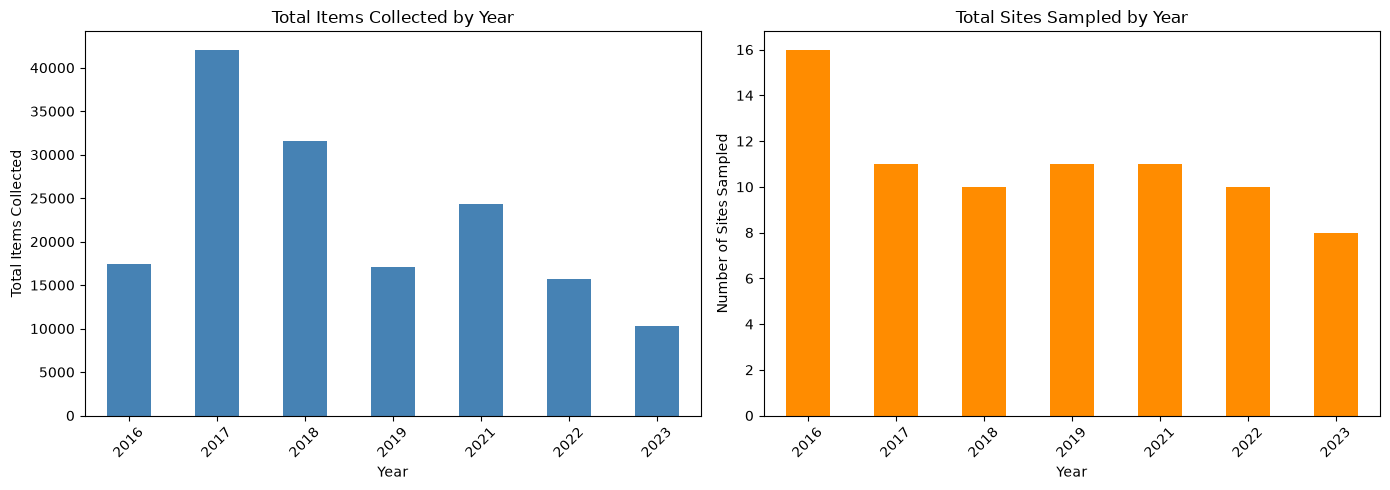

In [27]:
# Convert dates to datetime and extract the sampling year
data["Year"] = pd.to_datetime(data["Date"]).dt.year

year_summary = (
    data.groupby("Year")
    .agg(
        total_items=("Total Items Collected", "sum"),
        sites_sampled=("Area", "count"),
    )
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_summary["total_items"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue",
    title="Total Items Collected by Year",
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Items Collected")
axes[0].tick_params(axis="x", rotation=45)

year_summary["sites_sampled"].plot(
    kind="bar",
    ax=axes[1],
    color="darkorange",
    title="Total Sites Sampled by Year",
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Sites Sampled")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

This histogram compares the amount of items collected by year and the number of sites sampled by year. It's interesting that year with the most sites sampled does not align with the year with the most items collected (It is actually one of the lowest years in terms of items collected). From 2017 - 2023 the number of sites sampled seems to stay relatively consistent, but the items collected averages out to decreasing with each year. Used A.I. to help me build the structure for this.

,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
Total Items Collected,1.000000,0.667570,0.730760,0.808077,0.216578
Total Pounds of Litter Collected,0.667570,1.000000,0.672149,0.837152,0.212814
Number of Volunteers,0.730760,0.672149,1.000000,0.905277,0.510295
Volunteer Hours,0.808077,0.837152,0.905277,1.000000,0.302191
Number of Miles,0.216578,0.212814,0.510295,0.302191,1.000000


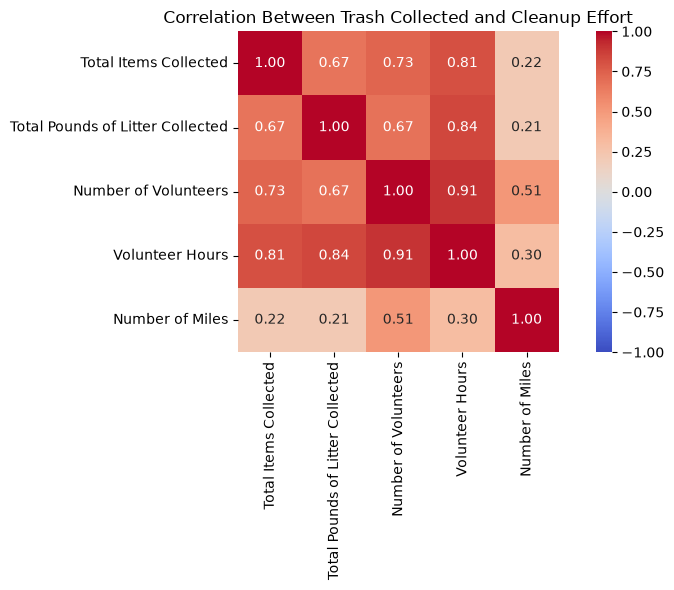

In [28]:
# Examine correlations between trash collected and cleanup variables
correlation_data = data[
    [
        "Total Items Collected",
        "Total Pounds of Litter Collected",
        "Number of Volunteers",
        "Volunteer Hours",
        "Number of Miles",
    ]
]

correlations = correlation_data.corr()
display(correlations)

# Plot the correlation matrix
plt.figure(figsize=(9, 6))
sea.heatmap(
    correlations,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
)
plt.title("Correlation Between Trash Collected and Cleanup Effort")
plt.tight_layout()
plt.show()

Looking at both the correlation plot and graph shows that the number of miles the cleanup occurred along was not well coordinated with many of the other variables. However, all others were decently well correlated. The amount of trash collected was better correlated with the number of hours than the number of volunteers (0.84, opposed to 0.67).

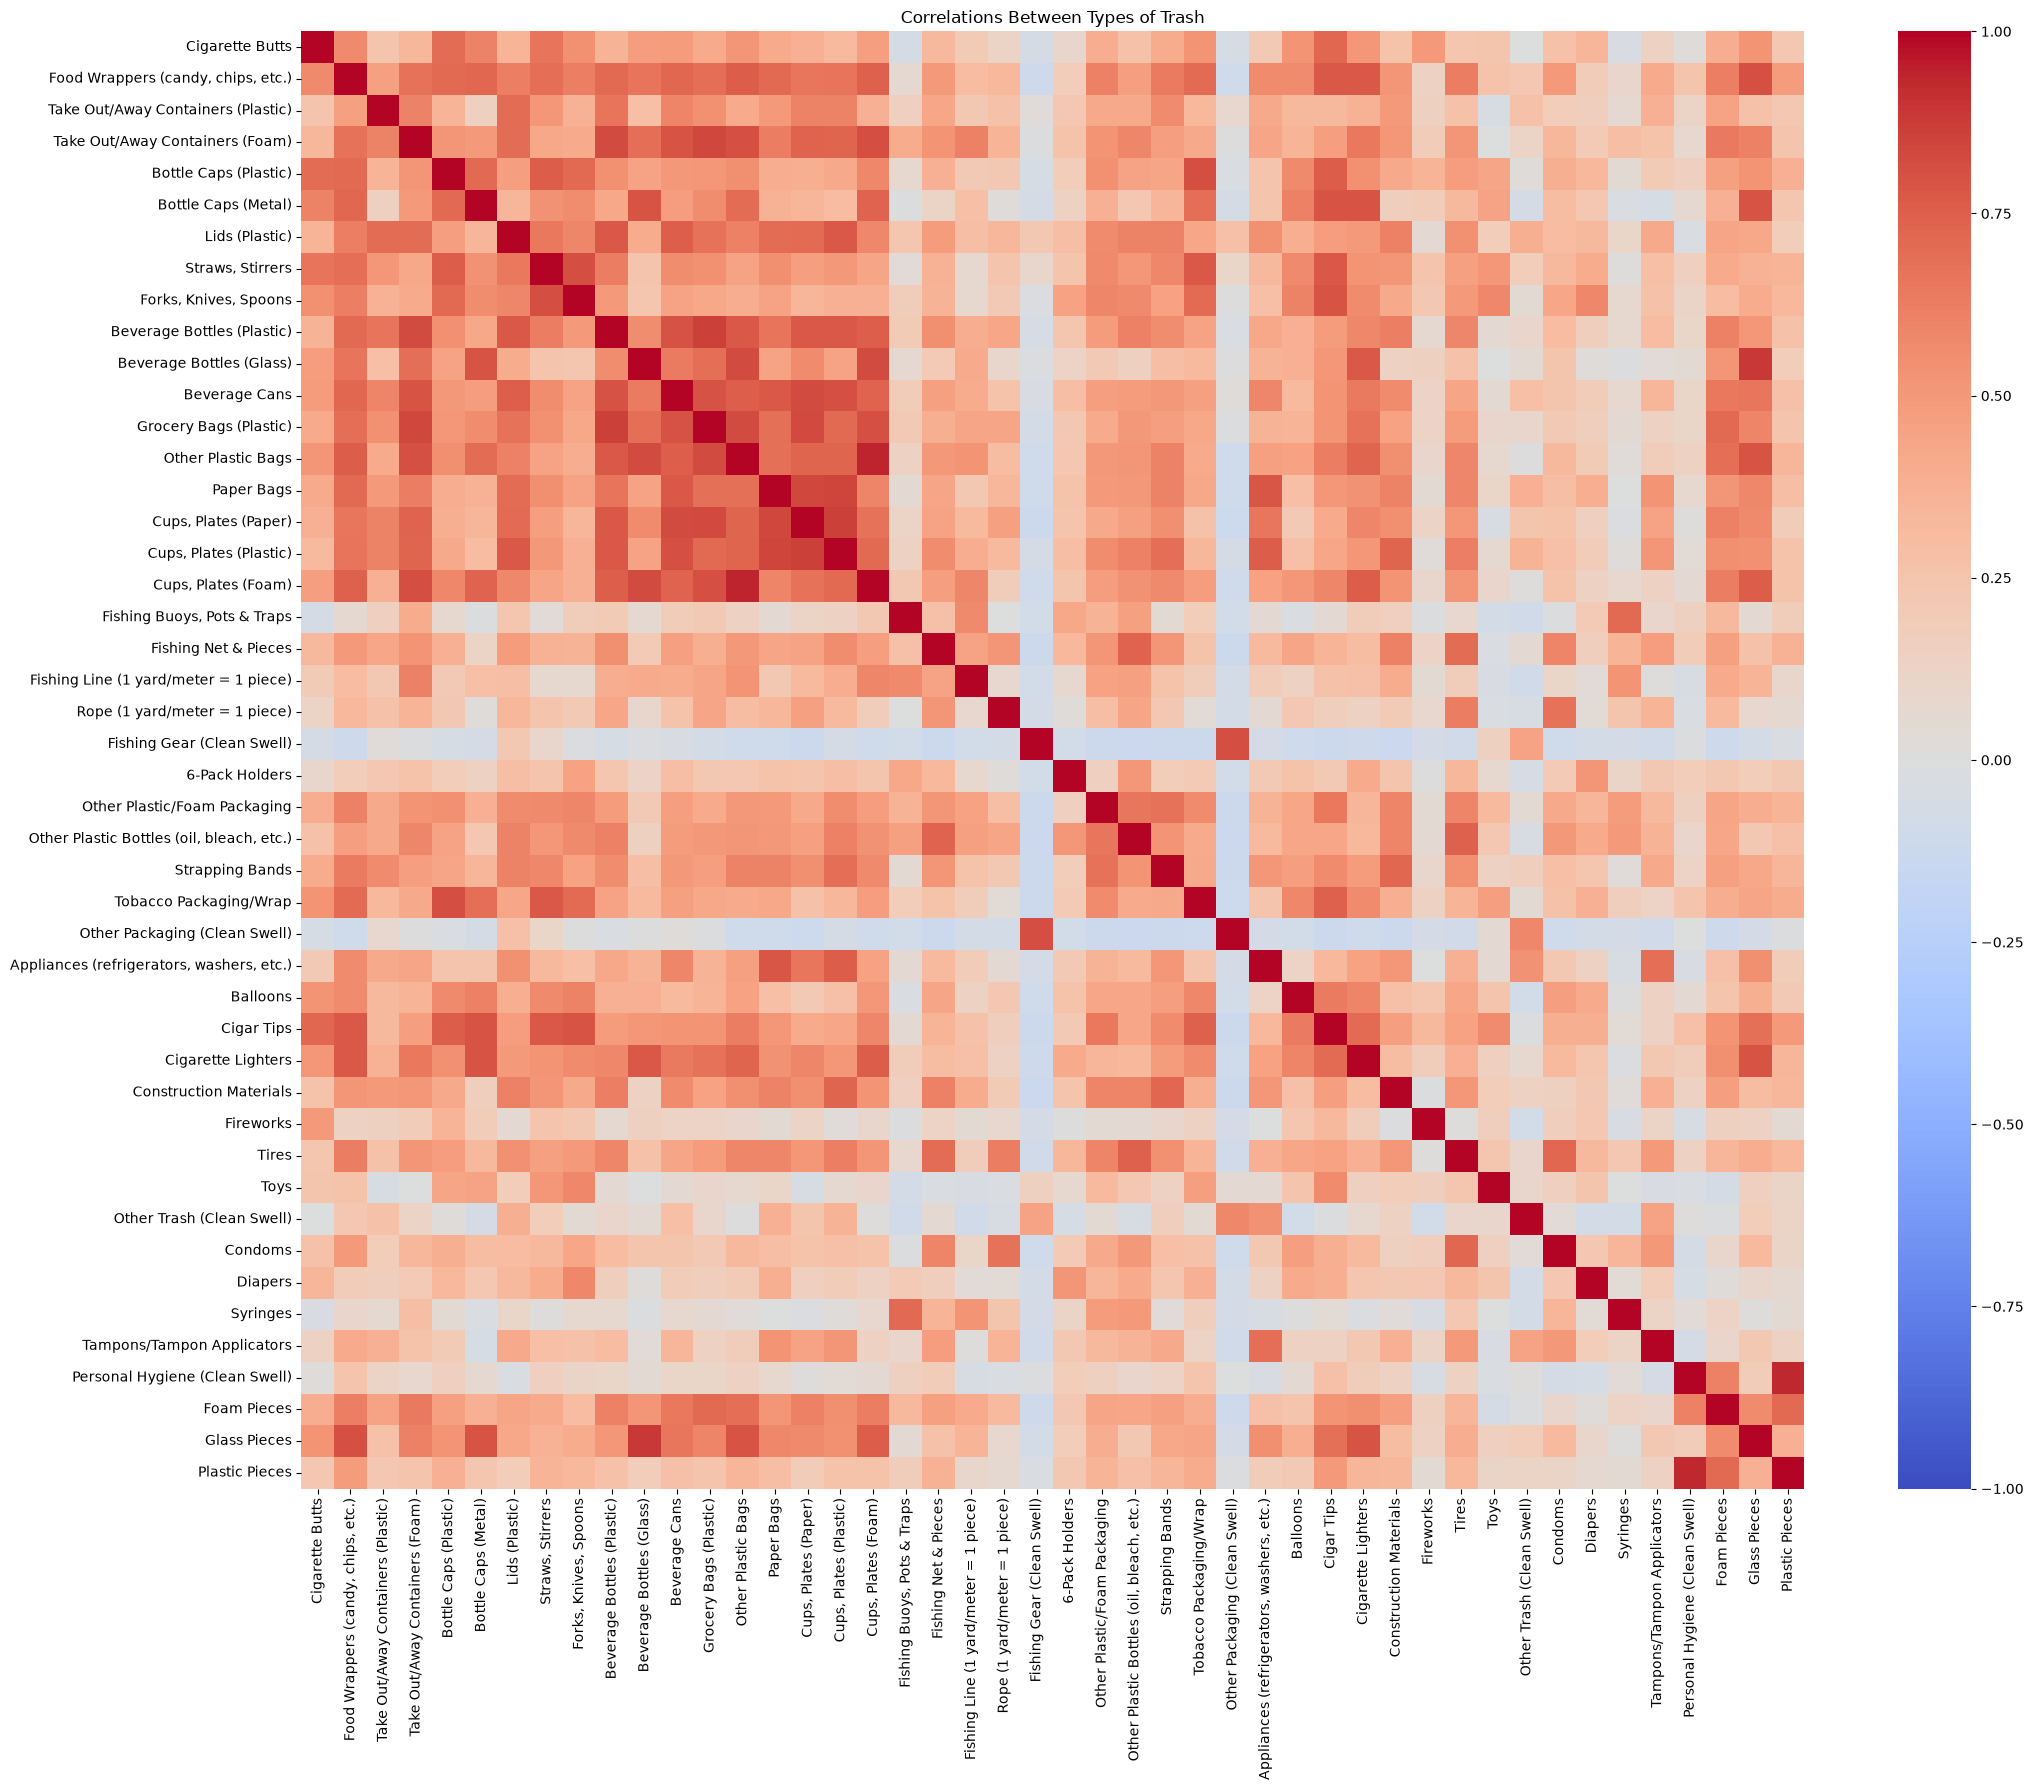

In [29]:
# Correlations among types of trash categories only
exclude_columns = [
    "Area",
    "Date",
    "Year",
    "Total Items Collected",
    "Total Pounds of Litter Collected",
    "Number of Volunteers",
    "Volunteer Hours",
    "Number of Miles",
]

trash_type_data = data.drop(columns=exclude_columns, errors="ignore")
trash_correlations = trash_type_data.corr()

# Plot the correlation matrix
fig, ax = plt.subplots(figsize=(22, 18))
sea.heatmap(
    trash_correlations,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    ax=ax,
)
ax.set_title("Correlations Between Types of Trash")
plt.tight_layout()
plt.show()

Looking at all of the different types of trash here is difficult to find any sort of trend. However there is a square in the top, left corner of plates, cups, and other cookout food and drink items. Everything else seems to be barely correlated. Fishing buoys, fishing gear, and other packaging were the least correlated of all variables.

Initial Conclusions:

This is an expansive dataset across 7 years (2017-2023) logging the collected trash litter at 36 unique sites and 77 total efforts of litter collection. I found that the most commonly found piece of littered trash were cigarette butts with food wrappers and foam pieces soon to follow. Overall, the data had a lot of individual variability within each separate data variable being collected. However, because of the large quantity of data collected taking information from the 25th, 50th, and 75th quartiles calculated is the most reliable way to get meaningful values out of the data. Increased analysis for such things as establishing the dirtiest beaches would revolve around correcting the amount of trash collected per site by the number of times the site was sampled. I could also look into the pounds of trash collected by site to get a better number of which place had the most trash by weight.